In [2]:
# # Cats vs Dogs Classification using Transfer Learning (MobileNetV2)

# ## Project Objective

# In this project, we will build a Cat vs Dog image classifier using Transfer Learning.

# Instead of training a CNN from scratch, we will use Google's pretrained MobileNetV2 model.

# By the end of this project, you will learn:

# - What is Transfer Learning?
# - What is a Pretrained Model?
# - What is ImageNet?
# - Why MobileNetV2?
# - How to Freeze a Model?
# - What is Fine-Tuning?

Import Required Libraries

In [3]:
import tensorflow as tf

from tensorflow import keras

import matplotlib.pyplot as plt

import numpy as np

import os

Import MobileNetV2

In [7]:
from tensorflow.keras.applications import MobileNetV2

Load Dataset

In [8]:
IMAGE_SIZE = (150, 150)

BATCH_SIZE = 32

In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(

    "../dataset/training_set",

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True

)

Found 8005 files belonging to 2 classes.


In [10]:
test_dataset = tf.keras.utils.image_dataset_from_directory(

    "../dataset/test_set",

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 2023 files belonging to 2 classes.


 Normalize Dataset

In [11]:
normalization_layer = keras.layers.Rescaling(

    1./255

)

train_dataset = train_dataset.map(

    lambda x, y: (normalization_layer(x), y)

)

test_dataset = test_dataset.map(

    lambda x, y: (normalization_layer(x), y)

)

 Optimize Dataset

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(

    AUTOTUNE

)

test_dataset = test_dataset.prefetch(

    AUTOTUNE

)

Load MobileNetV2

In [14]:
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(150,150,3)

)

C:\Users\Shubham Chauhan\AppData\Local\Temp\ipykernel_9764\393338925.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


 Freeze Base Model

In [15]:
base_model.trainable = False

Build Transfer Learning Model

In [16]:
model = keras.Sequential([

    base_model,

    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(

        128,

        activation="relu"

    ),

    keras.layers.Dropout(

        0.3

    ),

    keras.layers.Dense(

        1,

        activation="sigmoid"

    )

])

Display Model Summary

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile the Transfer Learning Model

In [18]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

Configure EarlyStopping

In [19]:
early_stop = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

Train the Transfer Learning Model

In [20]:
history = model.fit(

    train_dataset,

    validation_data=test_dataset,

    epochs=10,

    callbacks=[early_stop]

)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 165ms/step - accuracy: 0.9452 - loss: 0.1379 - val_accuracy: 0.9669 - val_loss: 0.0926
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.9654 - loss: 0.0893 - val_accuracy: 0.9694 - val_loss: 0.0848
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.9704 - loss: 0.0741 - val_accuracy: 0.9674 - val_loss: 0.0895
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - accuracy: 0.9751 - loss: 0.0637 - val_accuracy: 0.9654 - val_loss: 0.0983
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.9800 - loss: 0.0524 - val_accuracy: 0.9619 - val_loss: 0.1004


 Visualize Training Performance

In [22]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Plot Training and Validation Accuracy

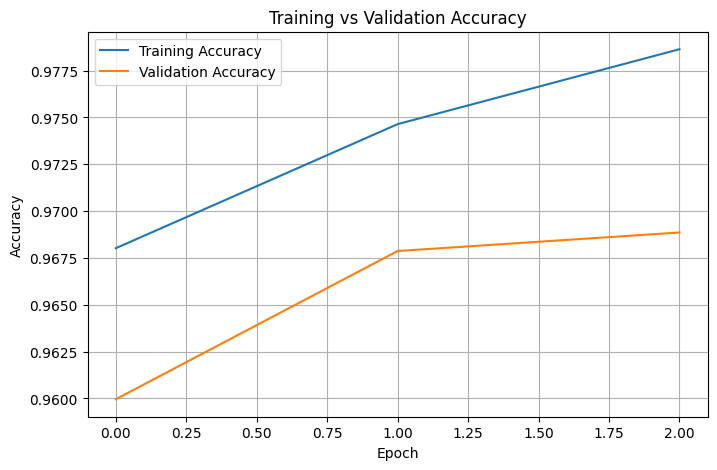

In [23]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Plot Training and Validation Loss

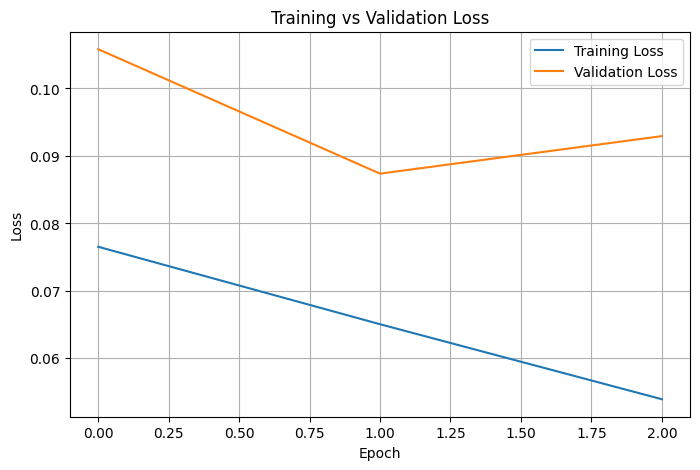

In [24]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

 Evaluate the Model

In [25]:
test_loss, test_accuracy = model.evaluate(

    test_dataset

)

print(f"Test Loss : {test_loss:.4f}")

print(f"Test Accuracy : {test_accuracy:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9600 - loss: 0.1058
Test Loss : 0.1058
Test Accuracy : 0.9600
